# Dataset-Level Attribution Analysis (U-ED-LSTM DomesticDeclarations)

This notebook computes and analyzes attribution patterns across the full dataset:

1. **Average feature attribution** for Activity, Resource, and temporal features
2. **Attribution by categorical value** for top-5 most common activities and resources
3. **Test mode** for quick validation with a subset

**Note**: Full dataset computation can take significant time. Use test mode first.

## 1. Setup

In [1]:
# Path setup and config import
import sys
from pathlib import Path

_current = Path().resolve()
while _current != _current.parent:
    if (_current / 'src').is_dir():
        break
    _current = _current.parent

# Add both project root and src/ to path (src/ needed for pickle compatibility)
if str(_current) not in sys.path:
    sys.path.insert(0, str(_current))
if str(_current / 'src') not in sys.path:
    sys.path.insert(0, str(_current / 'src'))

from src.interpretability.config.domestic_declarations_config import CONFIG
print(f"Dataset: {CONFIG.dataset_name}")

Dataset: DomesticDeclarations


In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from collections import defaultdict
import pickle
import random

from src.model.dropout_uncertainty_enc_dec_LSTM.dropout_uncertainty_model import DropoutUncertaintyEncoderDecoderLSTM
from src.evaluation.evaluation import Evaluation
from src.interpretability import InterpretabilityTool

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

# Reproducibility
SEED = CONFIG.seed
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [3]:
# Load model and data
model = DropoutUncertaintyEncoderDecoderLSTM.load(str(CONFIG.get_model_path()), dropout=0.0)
model.eval()
device = torch.device('cpu')
model = model.to(device)

test_dataset = torch.load(str(CONFIG.get_test_data_path()), weights_only=False)

eval_helper = Evaluation(
    model=model,
    dataset=test_dataset,
    concept_name=CONFIG.concept_name,
    growing_num_values=CONFIG.growing_num_values,
    all_cat=CONFIG.all_cat,
    all_num=CONFIG.all_num
)

tool = InterpretabilityTool(model, model.data_set_categories, device=device)

print(f"Loaded {len(test_dataset)} samples")
print(f"Available cases: {len(eval_helper.cases)}")

Data set categories:  ([('Activity', 10, {'APPROVED': 1, 'EOS': 2, 'FINAL_APPROVED': 3, 'FOR_APPROVAL': 4, 'Payment Handled': 5, 'REJECTED': 6, 'Request Payment': 7, 'SAVED': 8, 'SUBMITTED': 9}), ('Resource', 4, {'EOS': 1, 'STAFF MEMBER': 2, 'SYSTEM': 3}), ('Role', 9, {'ADMINISTRATION': 1, 'BUDGET OWNER': 2, 'EMPLOYEE': 3, 'EOS': 4, 'MISSING': 5, 'PRE_APPROVER': 6, 'SUPERVISOR': 7, 'UNDEFINED': 8})], [('case_elapsed_time', 1, {}), ('event_elapsed_time', 1, {}), ('day_in_week', 1, {}), ('seconds_in_day', 1, {}), ('Amount', 1, {})])
Encoder input features:  [['Activity', 'Resource', 'Role'], ['case_elapsed_time', 'event_elapsed_time', 'day_in_week', 'seconds_in_day', 'Amount']]
Decoder input+output features:  [['Activity', 'Resource'], ['case_elapsed_time', 'event_elapsed_time']]


Sequence length of decoder output:  4


Cells hidden size:  64
Number of LSTM layer:  2
Dropout rate:  0.0


Encoder number of labels for each input feature (categorical, numerical):  [[10, 4, 9], [1, 1, 1, 1,

Loaded 15471 samples
Available cases: 2100


## 2. Configuration

In [4]:
# ============================================================
# CONFIGURATION
# ============================================================
TEST_MODE = False          # Set to False for full dataset analysis
CONFIG.use_improved = False  # set True for the improved variant
TEST_SAMPLE_SIZE = 200     # Number of samples in test mode
IG_STEPS = 30             # Integration steps (reduce for speed)
TARGET = CONFIG.concept_name  # Attribution target

# Get ALL input features from the model (not a subset)
# This ensures attribution is always computed w.r.t. all input features
cat_categories, num_categories = model.data_set_categories
ALL_CAT_FEATURES = [name for name, _, _ in cat_categories]
ALL_NUM_FEATURES = [name for name, _, _ in num_categories]
ALL_FEATURES = ALL_CAT_FEATURES + ALL_NUM_FEATURES

print(f"Mode: {'TEST' if TEST_MODE else 'FULL'}")
print(f"All input features ({len(ALL_FEATURES)} total):")
print(f"  Categorical: {ALL_CAT_FEATURES}")
print(f"  Numerical: {ALL_NUM_FEATURES}")

Mode: FULL
All input features (8 total):
  Categorical: ['Activity', 'Resource', 'Role']
  Numerical: ['case_elapsed_time', 'event_elapsed_time', 'day_in_week', 'seconds_in_day', 'Amount']


## 3. Prepare Samples

In [5]:
# Collect all prefix-suffix pairs
all_samples = []

for case_name, full_case in tqdm(eval_helper.cases.items(), desc="Collecting samples"):
    for prefix_len, prefix, suffix in eval_helper._iterate_case(full_case):
        if prefix_len >= 1:  # At least 1 event
            all_samples.append({
                'case_name': case_name,
                'prefix_len': prefix_len,
                'prefix': prefix,
                'suffix': suffix
            })

print(f"Total samples: {len(all_samples)}")

# Sample if in test mode
if TEST_MODE:
    samples = random.sample(all_samples, min(TEST_SAMPLE_SIZE, len(all_samples)))
    print(f"Using {len(samples)} samples (test mode)")
else:
    samples = all_samples
    print(f"Using all {len(samples)} samples (full mode)")

Total samples: 9169
Using all 9169 samples (full mode)


## 4. Compute Attributions

In [6]:
# Compute attributions for all samples
attribution_results = []

for sample in tqdm(samples, desc="Computing attributions"):
    try:
        prefix = sample['prefix']
        prefix_len = sample['prefix_len']
        
        # Convert prefix
        cat_tensors = [t.squeeze(0) if t.dim() > 1 else t for t in prefix[0]]
        num_tensors = [t.squeeze(0) if t.dim() > 1 else t for t in prefix[1]]
        process = (cat_tensors, num_tensors)
        
        # Compute attribution
        attr_map = tool.compute_attribution_map(
            process=process,
            prefix_length=prefix_len,
            target=TARGET,
            target_class='auto',
            method='integrated_gradients',
            n_steps=IG_STEPS
        )
        
        # Extract feature attributions
        feature_attrs = {}
        for feat in attr_map.feature_names:
            if feat in attr_map.attributions:
                vals = attr_map.attributions[feat]
                if hasattr(vals, 'detach'):
                    vals = vals.detach().cpu().numpy()
                feature_attrs[feat] = np.abs(vals).sum()
        
        # Get predicted activity
        pred_activity = attr_map.target_description.split('=')[1].split('(')[0].strip() if '=' in attr_map.target_description else 'Unknown'
        
        attribution_results.append({
            'case_name': sample['case_name'],
            'prefix_len': prefix_len,
            'predicted_activity': pred_activity,
            **feature_attrs
        })
        
    except Exception as e:
        print(f"Error for {sample['case_name']}: {e}")

results_df = pd.DataFrame(attribution_results)
print(f"\nComputed attributions for {len(results_df)} samples")

Computing attributions:   0%|          | 0/9169 [00:00<?, ?it/s]


Computed attributions for 9169 samples


## 5. Average Feature Attribution (4 Views)

In [7]:
# Compute average attribution per feature
available_features = [f for f in ALL_FEATURES if f in results_df.columns]

avg_attribution = results_df[available_features].mean()
std_attribution = results_df[available_features].std()

print("Average Feature Attribution:")
print("="*60)
for feat in available_features:
    print(f"{feat:25s}: {avg_attribution[feat]:.6f} ± {std_attribution[feat]:.6f}")

Average Feature Attribution:
Activity                 : 0.996297 ± 0.292579
Resource                 : 0.586875 ± 0.406670
Role                     : 0.124119 ± 0.109782
case_elapsed_time        : 0.055914 ± 0.108167
event_elapsed_time       : 0.033317 ± 0.060916
day_in_week              : 0.006291 ± 0.006608
seconds_in_day           : 0.022532 ± 0.023682
Amount                   : 0.007439 ± 0.014069


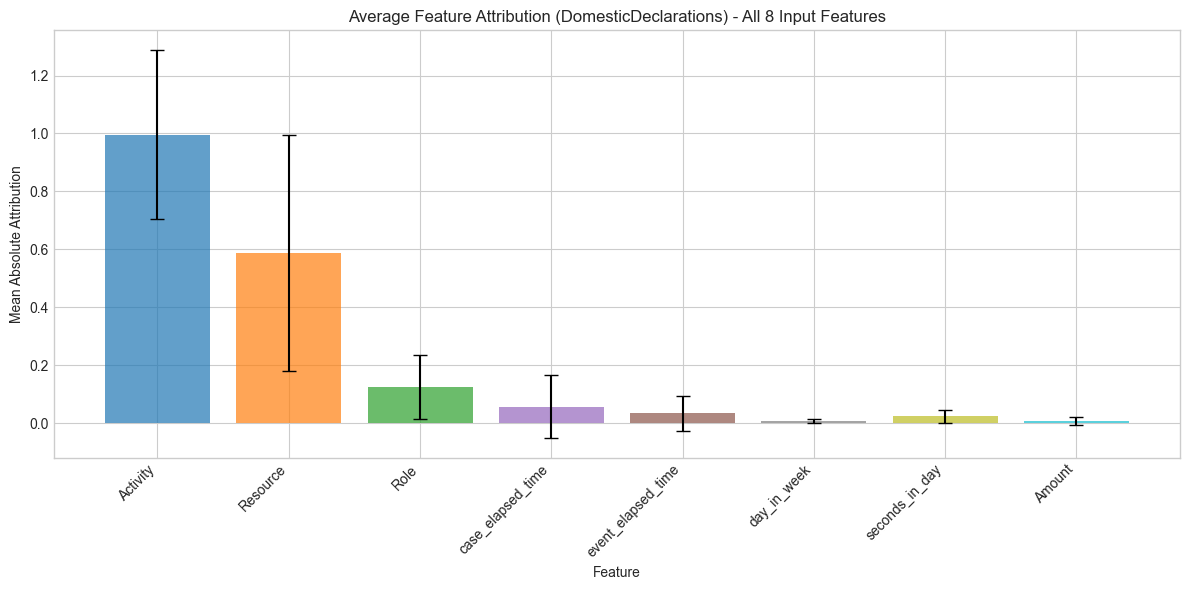

In [8]:
# View 1: Bar chart of average attribution
fig, ax = plt.subplots(figsize=(12, 6))

# Use a colormap that scales with number of features
colors = plt.cm.tab10(np.linspace(0, 1, len(available_features)))
bars = ax.bar(available_features, avg_attribution[available_features], 
              yerr=std_attribution[available_features], capsize=5, 
              color=colors, alpha=0.7)

ax.set_ylabel('Mean Absolute Attribution')
ax.set_xlabel('Feature')
ax.set_title(f'Average Feature Attribution ({CONFIG.dataset_name}) - All {len(available_features)} Input Features')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

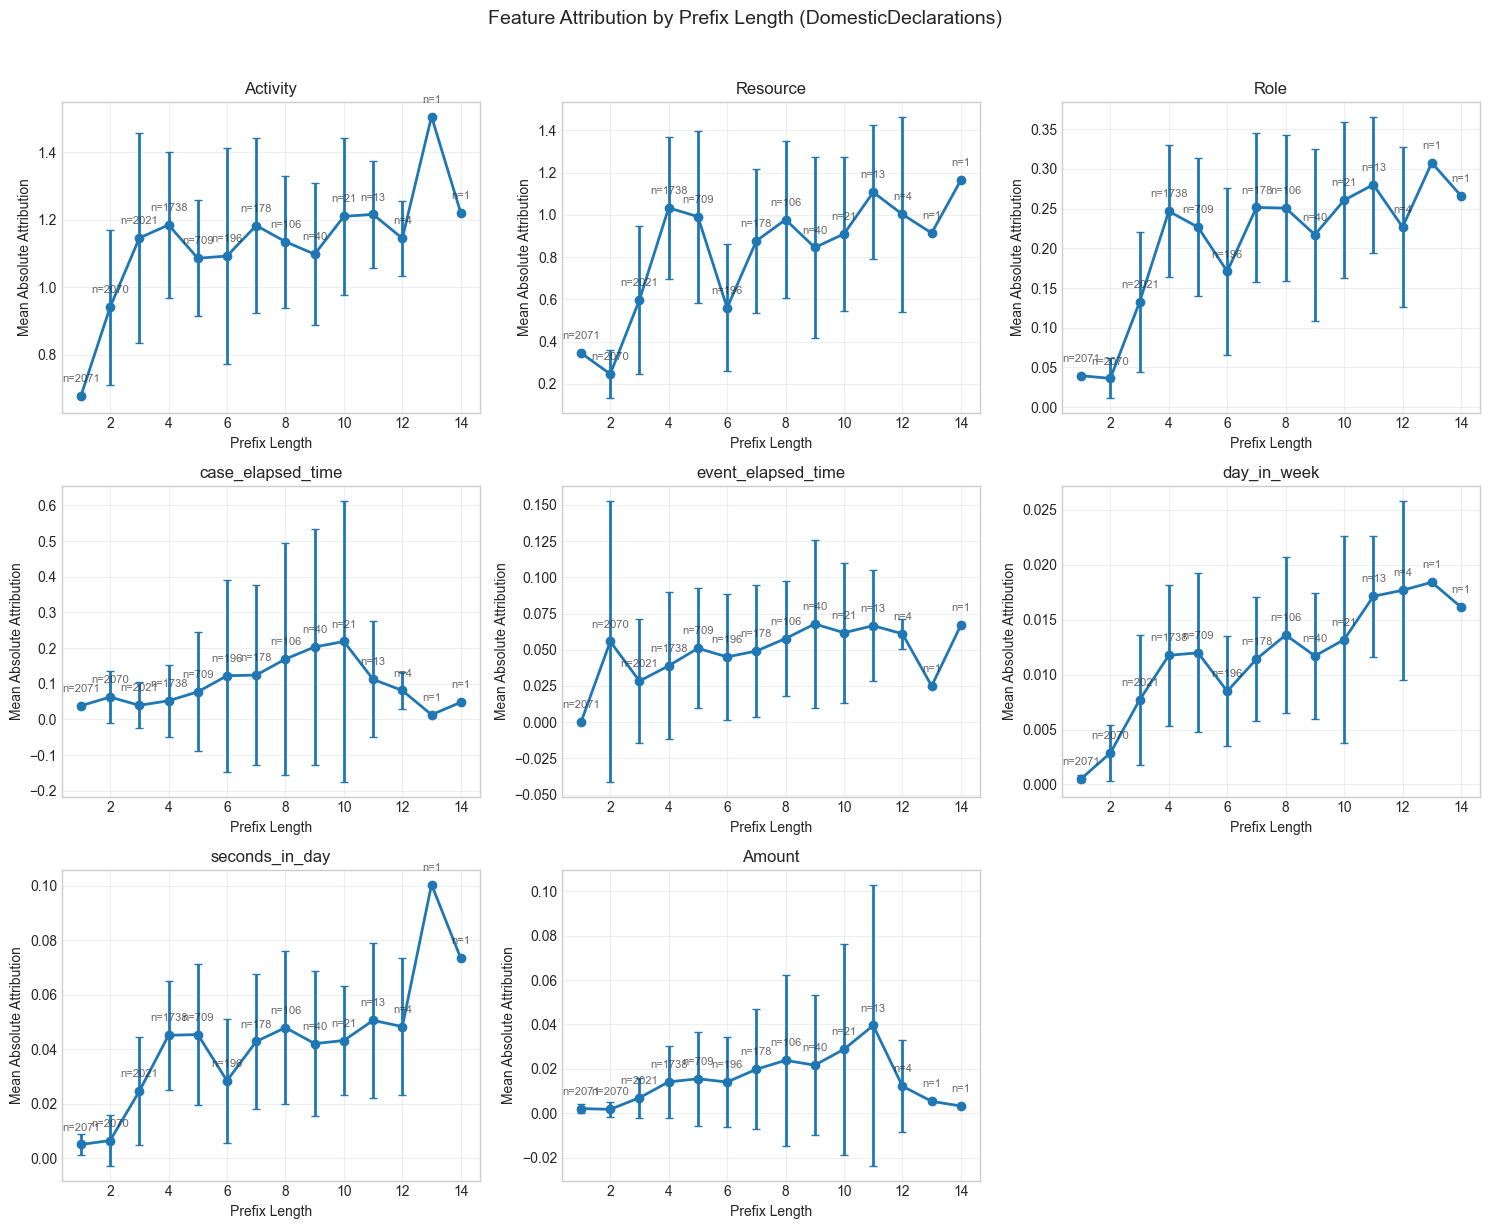


Sample distribution by prefix length:
  Prefix 1: n=2071
  Prefix 2: n=2070
  Prefix 3: n=2021
  Prefix 4: n=1738
  Prefix 5: n=709
  Prefix 6: n=196
  Prefix 7: n=178
  Prefix 8: n=106
  Prefix 9: n=40
  Prefix 10: n=21
  Prefix 11: n=13
  Prefix 12: n=4
  Prefix 13: n=1
  Prefix 14: n=1


In [9]:
# View 3: Attribution by prefix length
n_features = len(available_features)
n_cols = min(3, n_features)
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
if n_features == 1:
    axes = [axes]
else:
    axes = axes.flatten() if n_features > 1 else [axes]

# Get sample counts per prefix length
prefix_counts = results_df.groupby('prefix_len').size()

for idx, feat in enumerate(available_features):
    ax = axes[idx]
    
    # Group by prefix length
    grouped = results_df.groupby('prefix_len')[feat].agg(['mean', 'std'])
    
    ax.errorbar(grouped.index, grouped['mean'], yerr=grouped['std'], 
                marker='o', capsize=3, linewidth=2, markersize=6)
    ax.set_xlabel('Prefix Length')
    ax.set_ylabel('Mean Absolute Attribution')
    ax.set_title(f'{feat}')
    ax.grid(True, alpha=0.3)
    
    # Add sample count annotations
    for pl in grouped.index:
        n = prefix_counts[pl]
        ax.annotate(f'n={n}', (pl, grouped.loc[pl, 'mean']), 
                    textcoords="offset points", xytext=(0, 10), 
                    ha='center', fontsize=8, alpha=0.7)

# Hide unused subplots
for idx in range(n_features, len(axes)):
    axes[idx].axis('off')

plt.suptitle(f'Feature Attribution by Prefix Length ({CONFIG.dataset_name})', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Print sample distribution
print("\nSample distribution by prefix length:")
for pl in sorted(prefix_counts.index):
    print(f"  Prefix {pl}: n={prefix_counts[pl]}")

## 6. Attribution by Categorical Value (10 Views)

In [10]:
# Find top-5 most common predicted activities
activity_counts = results_df['predicted_activity'].value_counts()
top_activities = activity_counts.head(5).index.tolist()

print(f"Top 5 predicted activities:")
for act in top_activities:
    print(f"  {act}: {activity_counts[act]} predictions")

Top 5 predicted activities:
  APPROVED: 2766 predictions
  FINAL_APPROVED: 2365 predictions
  Request Payment: 2040 predictions
  Payment Handled: 1998 predictions


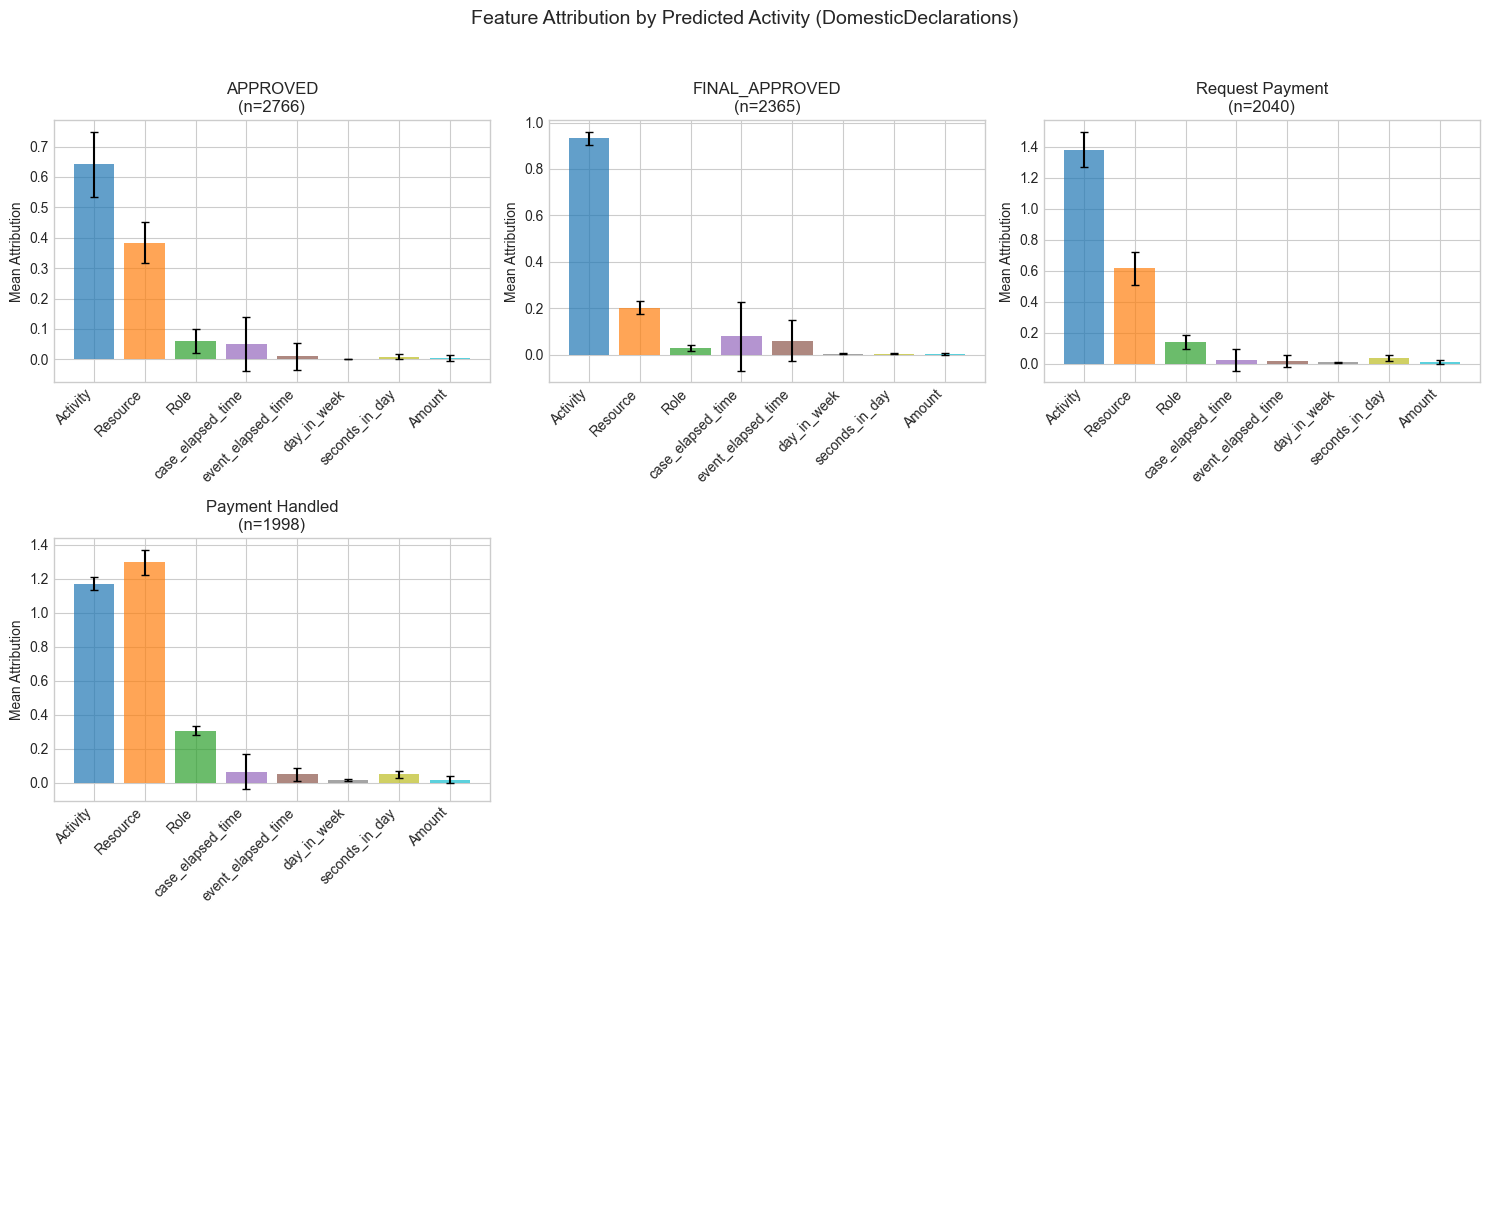

In [11]:
# Views 1-5: Attribution for each of top-5 activities
n_activities = min(5, len(top_activities))
n_cols = min(3, n_activities)
n_rows = (n_activities + n_cols - 1) // n_cols + (1 if n_activities % n_cols != 0 else 0)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten() if n_activities > 1 else [axes]

# Use colormap for dynamic number of features
colors = plt.cm.tab10(np.linspace(0, 1, len(available_features)))

for idx, activity in enumerate(top_activities[:n_activities]):
    ax = axes[idx]
    
    # Filter to this activity
    activity_df = results_df[results_df['predicted_activity'] == activity]
    
    if len(activity_df) > 0:
        means = activity_df[available_features].mean()
        stds = activity_df[available_features].std()
        
        ax.bar(range(len(available_features)), means, yerr=stds, capsize=3,
               color=colors, alpha=0.7)
        ax.set_xticks(range(len(available_features)))
        ax.set_xticklabels(available_features, rotation=45, ha='right')
        ax.set_ylabel('Mean Attribution')
        ax.set_title(f'{activity}\n(n={len(activity_df)})')

# Hide unused subplots
for idx in range(n_activities, len(axes)):
    axes[idx].axis('off')

plt.suptitle(f'Feature Attribution by Predicted Activity ({CONFIG.dataset_name})', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [12]:
# Summary table: Attribution by activity
activity_summary = []

for activity in top_activities:
    activity_df = results_df[results_df['predicted_activity'] == activity]
    
    row = {'Activity': activity, 'Count': len(activity_df)}
    for feat in available_features:
        row[f'{feat}_mean'] = activity_df[feat].mean()
    activity_summary.append(row)

summary_df = pd.DataFrame(activity_summary)
print("\nAttribution Summary by Predicted Activity:")
display(summary_df)


Attribution Summary by Predicted Activity:


,Activity,Count,Activity_mean,Resource_mean,Role_mean,case_elapsed_time_mean,event_elapsed_time_mean,day_in_week_mean,seconds_in_day_mean,Amount_mean
0,APPROVED,2766,0.641378,0.383969,0.060345,0.051296,0.009527,0.001002,0.008619,0.004712
1,FINAL_APPROVED,2365,0.932162,0.201562,0.028415,0.079483,0.059364,0.003036,0.004234,0.001611
2,Request Payment,2040,1.381682,0.614761,0.142973,0.025751,0.020242,0.008846,0.035606,0.008758
3,Payment Handled,1998,1.170074,1.295393,0.306441,0.065204,0.048769,0.014856,0.050101,0.016765


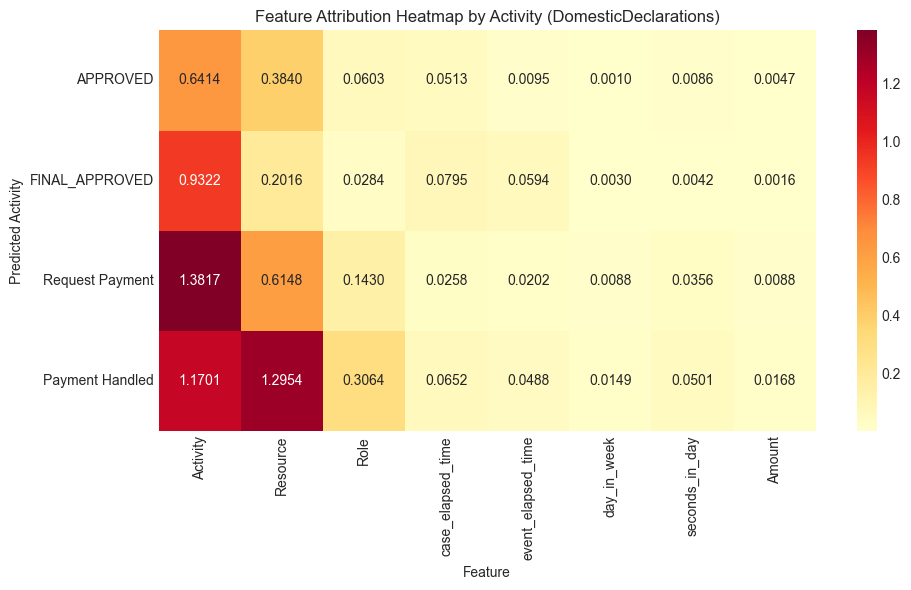

In [13]:
# Views 6-10: Heatmap of feature attribution by activity
# Create pivot table
heatmap_data = summary_df.set_index('Activity')[[f'{f}_mean' for f in available_features]]
heatmap_data.columns = available_features

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, cmap='YlOrRd', fmt='.4f', ax=ax)
ax.set_title(f'Feature Attribution Heatmap by Activity ({CONFIG.dataset_name})')
ax.set_ylabel('Predicted Activity')
ax.set_xlabel('Feature')
plt.tight_layout()
plt.show()

## 7. Save Results

In [14]:
# Save results
output_dir = CONFIG.get_results_dir()

mode_suffix = '_test' if TEST_MODE else '_full'
output_path = output_dir / f'dataset_attribution_results{mode_suffix}.pkl'

with open(output_path, 'wb') as f:
    pickle.dump({
        'results_df': results_df,
        'avg_attribution': avg_attribution.to_dict(),
        'activity_summary': summary_df,
        'config': CONFIG.to_dict(),
        'test_mode': TEST_MODE
    }, f)

print(f"Results saved to: {output_path}")

Results saved to: /Users/philippeichhorn/IdeaProjects/XAI-Probabilistic_Suffix_Prediction_U-ED-LSTM_pub/src/interpretability/notebooks/results/domesticdeclarations/dataset_attribution_results_full.pkl


## 8. Summary

In [15]:
print("="*80)
print(f"SUMMARY: Dataset-Level Attribution Analysis")
print("="*80)
print(f"\nDataset: {CONFIG.dataset_name}")
print(f"Mode: {'TEST' if TEST_MODE else 'FULL'}")
print(f"Samples analyzed: {len(results_df)}")
print(f"Total input features: {len(available_features)}")

print(f"\n--- Average Feature Attribution (All {len(available_features)} Features) ---")
# Sort by attribution value
sorted_attrs = avg_attribution[available_features].sort_values(ascending=False)
for feat in sorted_attrs.index:
    print(f"{feat:25s}: {sorted_attrs[feat]:.6f}")

print(f"\n--- Top Predicted Activities ---")
for act in top_activities[:5]:
    print(f"{act}: {activity_counts[act]} predictions")

SUMMARY: Dataset-Level Attribution Analysis

Dataset: DomesticDeclarations
Mode: FULL
Samples analyzed: 9169
Total input features: 8

--- Average Feature Attribution (All 8 Features) ---
Activity                 : 0.996297
Resource                 : 0.586875
Role                     : 0.124119
case_elapsed_time        : 0.055914
event_elapsed_time       : 0.033317
seconds_in_day           : 0.022532
Amount                   : 0.007439
day_in_week              : 0.006291

--- Top Predicted Activities ---
APPROVED: 2766 predictions
FINAL_APPROVED: 2365 predictions
Request Payment: 2040 predictions
Payment Handled: 1998 predictions
